### Assignment 1 on Intensity Transformations and Neighborhood Filtering

In [32]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

### Question 1

In [33]:
img_orig = cv.imread('images/runway.png', cv.IMREAD_GRAYSCALE)
assert img_orig is not None, "Image not found. Please check the path."

def get_gamma(gamma):
    return np.array([((i / 255.0) ** gamma) * 255 for i in range(256)], dtype=np.uint8)

In [34]:
gamma_05 = get_gamma(0.5)
gamma_20 = get_gamma(2.0)

img_gamma_05 = cv.LUT(img_orig, gamma_05)
img_gamma_20 = cv.LUT(img_orig, gamma_20)

In [ ]:
def contrast_stretching(image, r1=0.2, r2=0.8):
    r = image.astype(float) / 255.0
    
    s = (r - r1) / (r2 - r1)
    
    # Values < r1 will result in s < 0 -> clipped to 0
    # Values > r2 will result in s > 1 -> clipped to 1
    s = np.clip(s, 0, 1)
    
    output = (s * 255).astype(np.uint8)
    
    return output

r1_val = 0.2
r2_val = 0.8

# Apply transformation
img_stretch = contrast_stretching(img_orig, r1=r1_val, r2=r2_val)

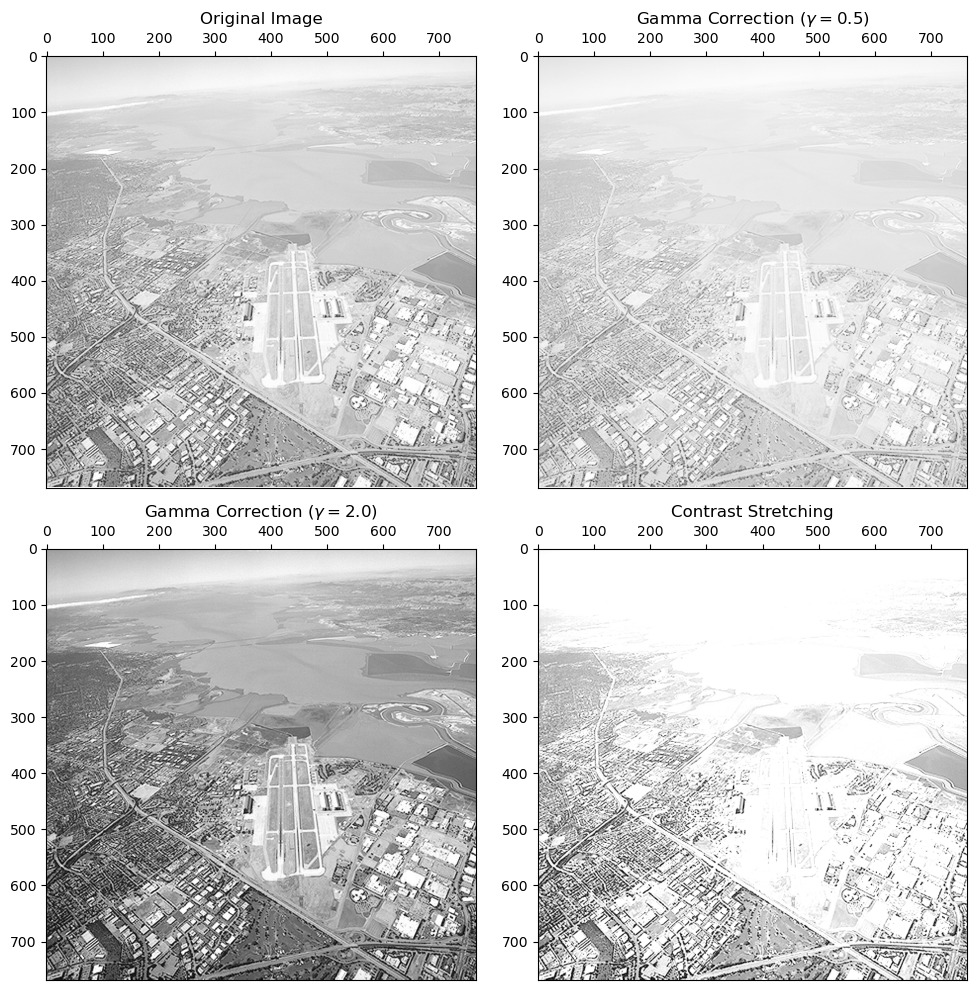

In [36]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))

# Original
ax[0, 0].imshow(img_orig, cmap='gray', vmin=0, vmax=255)
ax[0, 0].set_title('Original Image')
ax[0, 0].xaxis.set_ticks_position('top')

# Gamma 0.5
ax[0, 1].imshow(img_gamma_05, cmap='gray', vmin=0, vmax=255)
ax[0, 1].set_title(r'Gamma Correction ($\gamma=0.5$)')
ax[0, 1].xaxis.set_ticks_position('top')

# Gamma 2.0
ax[1, 0].imshow(img_gamma_20, cmap='gray', vmin=0, vmax=255)
ax[1, 0].set_title(r'Gamma Correction ($\gamma=2.0$)')
ax[1, 0].xaxis.set_ticks_position('top')

# Contrast Stretching
ax[1, 1].imshow(img_stretch, cmap='gray', vmin=0, vmax=255)
ax[1, 1].set_title('Contrast Stretching')
ax[1, 1].xaxis.set_ticks_position('top')

plt.tight_layout()
plt.show()

### Question 2

C:\Users\Neths\AppData\Local\Temp\ipykernel_11540\180589717.py:26: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(l_channel.ravel(), 256, [0, 256], color='black')
C:\Users\Neths\AppData\Local\Temp\ipykernel_11540\180589717.py:31: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(l_corrected.ravel(), 256, [0, 256], color='blue')


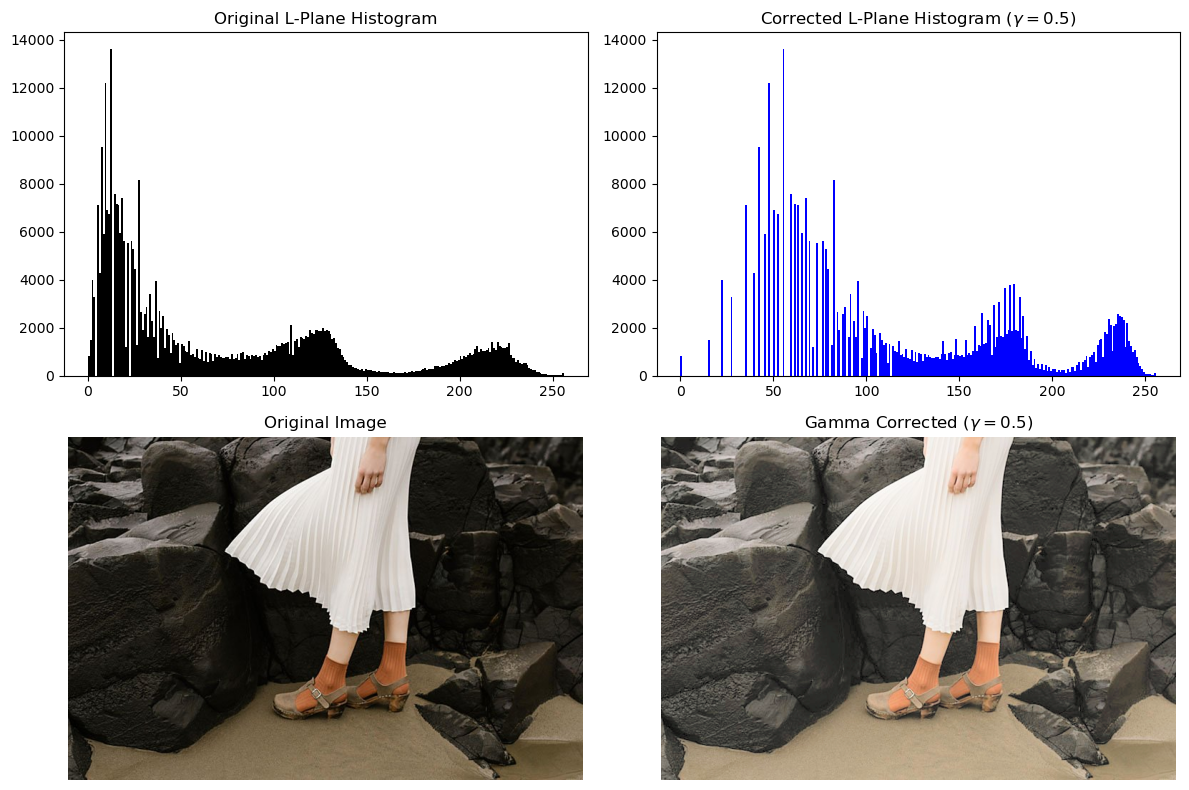

In [ ]:
img = cv.imread('images/highlights_and_shadows.jpg')

assert img is not None, "Image not found. Please check the path."

lab = cv.cvtColor(img, cv.COLOR_BGR2LAB)
l_channel, a_channel, b_channel = cv.split(lab)

l_normalized = l_channel.astype(np.float32) / 255.0
gamma = 0.5  
l_gamma = np.power(l_normalized, gamma)

l_corrected = (l_gamma * 255).astype(np.uint8)

lab_corrected = cv.merge([l_corrected, a_channel, b_channel])
corrected_img = cv.cvtColor(lab_corrected, cv.COLOR_LAB2RGB)
original_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))

# Original L Histogram
plt.subplot(2, 2, 1)
plt.title("Original L-Plane Histogram")
plt.hist(l_channel.ravel(), 256, [0, 256], color='black')

# Corrected L Histogram
plt.subplot(2, 2, 2)
plt.title(f"Corrected L-Plane Histogram ($\gamma={gamma}$)")
plt.hist(l_corrected.ravel(), 256, [0, 256], color='blue')

# Visual Comparison
plt.subplot(2, 2, 3)
plt.title("Original Image")
plt.imshow(original_rgb)
plt.axis('off')

plt.subplot(2, 2, 4)
plt.title(f"Gamma Corrected ($\gamma={gamma}$)")
plt.imshow(corrected_img)
plt.axis('off')

plt.tight_layout()
plt.show()

### Question 3

C:\Users\Neths\AppData\Local\Temp\ipykernel_11540\607575361.py:29: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(2, 2, 3); plt.hist(img.flatten(), 256, [0,256]); plt.title("Original Hist")
C:\Users\Neths\AppData\Local\Temp\ipykernel_11540\607575361.py:30: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(2, 2, 4); plt.hist(equalized_img.flatten(), 256, [0,256]); plt.title("Equalized Hist")


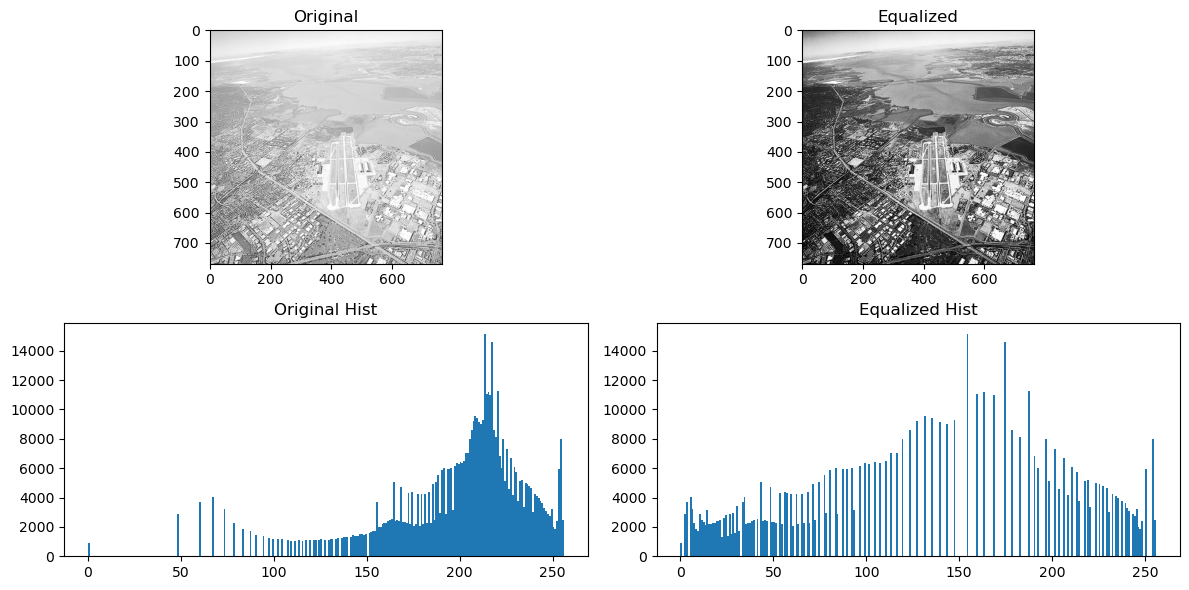

In [ ]:
def histogram_equalization(image):
    M, N = image.shape[:2]
    L = 256

    hist, bins = np.histogram(image.flatten(), L, [0, L])

    cumulative_sum = hist.cumsum()
 
    transformation_factor = (L - 1) / (M * N)
    s_k = np.round(cumulative_sum * transformation_factor).astype('uint8')
    equalized_image = s_k[image]
    
    return equalized_image

img = cv.imread('images/runway.png', cv.IMREAD_GRAYSCALE)
assert img is not None, "Image not found. Please check the path."

equalized_img = histogram_equalization(img)

plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1); plt.title("Original"); plt.imshow(img, cmap='gray')
plt.subplot(2, 2, 2); plt.title("Equalized"); plt.imshow(equalized_img, cmap='gray')
plt.subplot(2, 2, 3); plt.hist(img.flatten(), 256, [0,256]); plt.title("Original Hist")
plt.subplot(2, 2, 4); plt.hist(equalized_img.flatten(), 256, [0,256]); plt.title("Equalized Hist")
plt.tight_layout()
plt.show()

### Question 4

In [46]:
img_gray = cv.imread('images/ronak-valobobhai-6YzA45_b2vA-unsplash.jpg', cv.IMREAD_GRAYSCALE)
assert img_gray is not None, "Image not found. Please check the path."

threshold_val, mask = cv.threshold(img_gray, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)
print(f"Reported Otsu Threshold Value: {threshold_val}")

Reported Otsu Threshold Value: 101.0


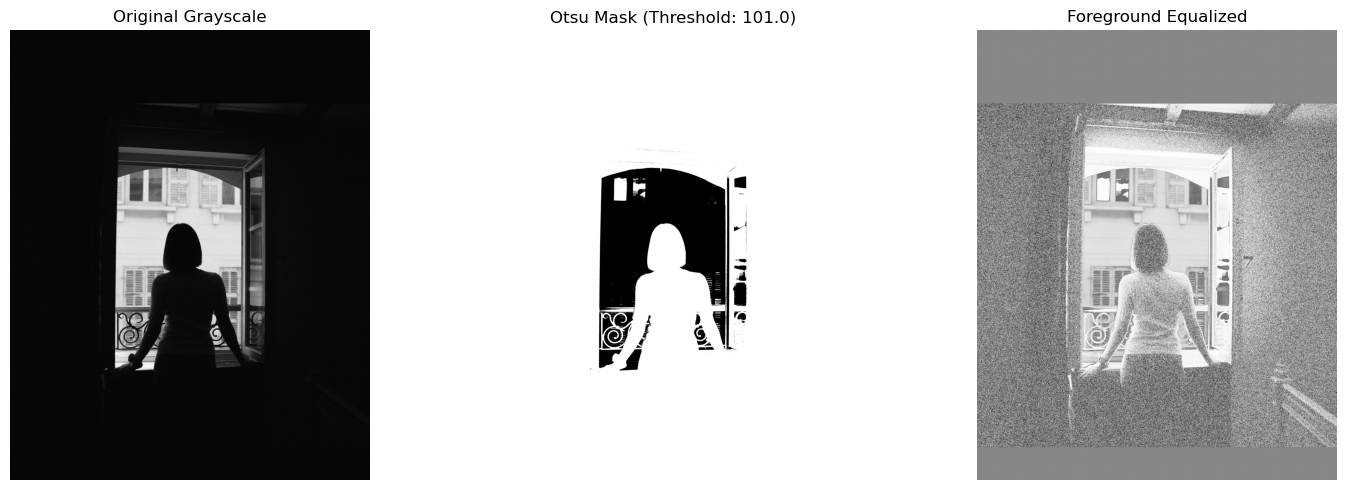

In [ ]:
foreground_indices = np.where(mask == 255)
foreground_pixels = img_gray[foreground_indices]

M_N_foreground = foreground_pixels.size
L = 256

hist, bins = np.histogram(foreground_pixels, L, [0, L])

cumulative_sum = hist.cumsum()

transformation_factor = (L - 1) / M_N_foreground
s_k = np.round(cumulative_sum * transformation_factor).astype('uint8')

result_img = img_gray.copy()
result_img[foreground_indices] = s_k[foreground_pixels]

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Original Grayscale")
plt.imshow(img_gray, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title(f"Otsu Mask (Threshold: {threshold_val})")
plt.imshow(mask, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Foreground Equalized")
plt.imshow(result_img, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

(b) Details in the woman's clothing and the room walls that were previously "crushed" into near-black become visible.

### Question 5

5x5 Gaussian Kernel (sigma=2):
[[0.02324684 0.03382395 0.03832756 0.03382395 0.02324684]
 [0.03382395 0.04921356 0.05576627 0.04921356 0.03382395]
 [0.03832756 0.05576627 0.06319146 0.05576627 0.03832756]
 [0.03382395 0.04921356 0.05576627 0.04921356 0.03382395]
 [0.02324684 0.03382395 0.03832756 0.03382395 0.02324684]]


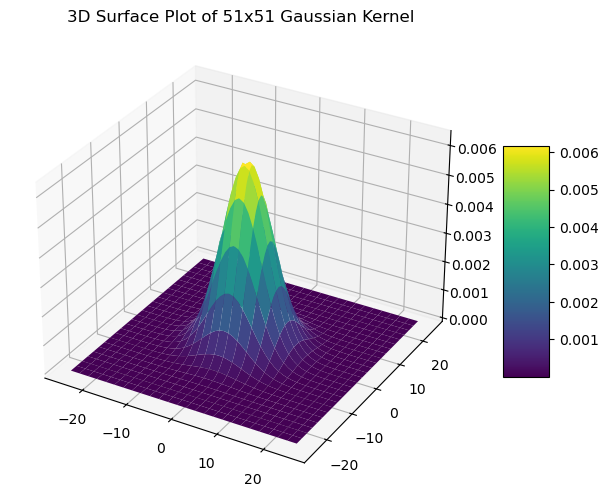

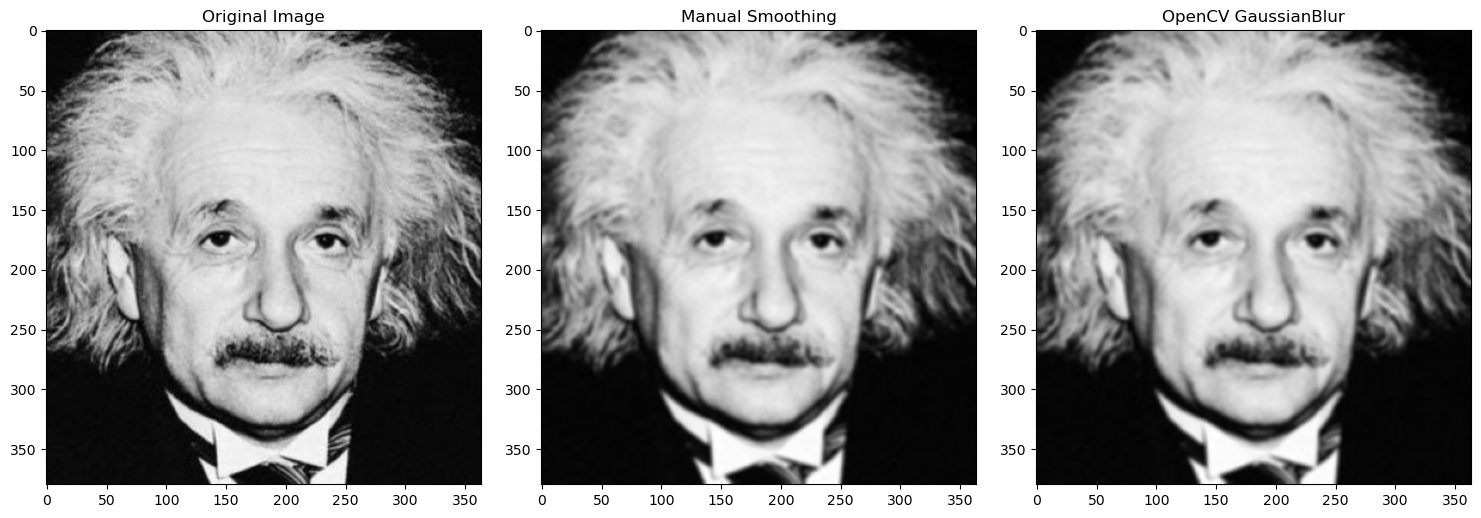

In [50]:
def create_gaussian_kernel(size, sigma):
    ax = np.linspace(-(size // 2), size // 2, size)
    x, y = np.meshgrid(ax, ax)
    kernel = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    return kernel / np.sum(kernel)

kernel_5x5 = create_gaussian_kernel(5, 2)
print("5x5 Gaussian Kernel (sigma=2):")
print(kernel_5x5)

kernel_51x51 = create_gaussian_kernel(51, 5) 
size = 51
ax_range = np.linspace(-(size // 2), size // 2, size)
X, Y = np.meshgrid(ax_range, ax_range)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, kernel_51x51, cmap='viridis', edgecolor='none')
ax.set_title("3D Surface Plot of 51x51 Gaussian Kernel")
plt.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

image = cv.imread('images/einstein.png', cv.IMREAD_GRAYSCALE)
assert image is not None, "Image not found. Please check the path."

manual_smooth = cv.filter2D(image, -1, kernel_5x5)

opencv_smooth = cv.GaussianBlur(image, (5, 5), 2)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.title("Original Image"); plt.imshow(image, cmap='gray')
plt.subplot(1, 3, 2); plt.title("Manual Smoothing"); plt.imshow(manual_smooth, cmap='gray')
plt.subplot(1, 3, 3); plt.title("OpenCV GaussianBlur"); plt.imshow(opencv_smooth, cmap='gray')
plt.tight_layout()
plt.show()

### Question 6

In [ ]:
def get_dog_kernels(size, sigma):
    ax = np.linspace(-(size // 2), size // 2, size)
    x, y = np.meshgrid(ax, ax)

    g = (1 / (2 * np.pi * sigma**2)) * np.exp(-(x**2 + y**2) / (2 * sigma**2))
    gx = -(x / sigma**2) * g
    gy = -(y / sigma**2) * g
    
    return gx, gy

gx_5, gy_5 = get_dog_kernels(5, 2)
print("5x5 Derivative-of-Gaussian Kernel (X direction):")
print(gx_5)

5x5 Derivative-of-Gaussian Kernel (X direction):
[[ 0.00731873  0.00532434 -0.         -0.00532434 -0.00731873]
 [ 0.01064869  0.00774687 -0.         -0.00774687 -0.01064869]
 [ 0.01206654  0.00877836 -0.         -0.00877836 -0.01206654]
 [ 0.01064869  0.00774687 -0.         -0.00774687 -0.01064869]
 [ 0.00731873  0.00532434 -0.         -0.00532434 -0.00731873]]


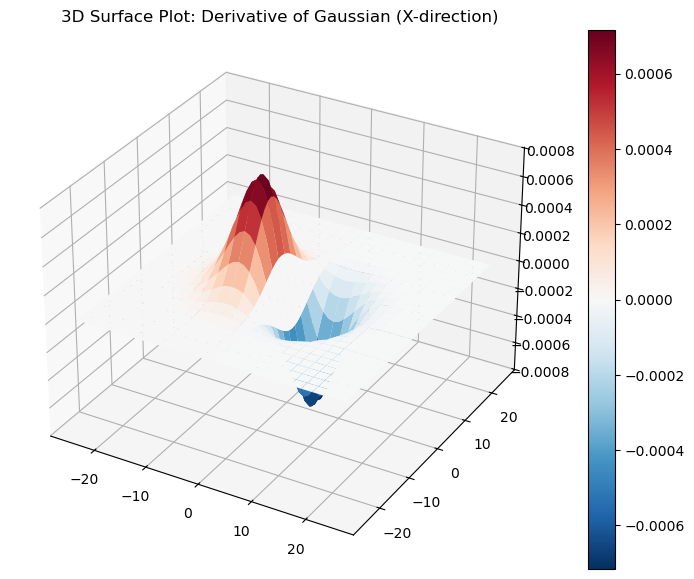

In [54]:
gx_51, gy_51 = get_dog_kernels(51, 5)
size = 51
ax_range = np.linspace(-(size // 2), size // 2, size)
X, Y = np.meshgrid(ax_range, ax_range)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, gx_51, cmap='RdBu_r', edgecolor='none')
ax.set_title("3D Surface Plot: Derivative of Gaussian (X-direction)")
plt.colorbar(surf)
plt.show()

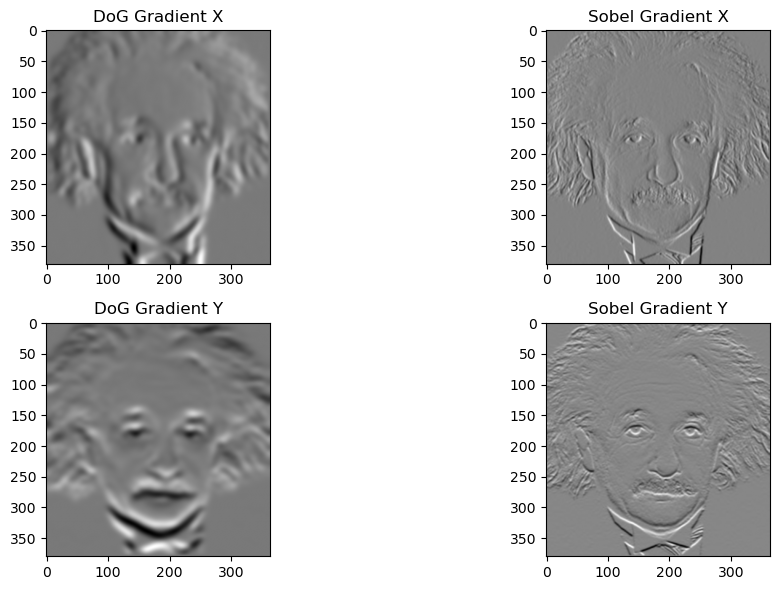

In [ ]:
img = cv.imread('images/einstein.png', cv.IMREAD_GRAYSCALE)
assert img is not None, "Image not found. Please check the path."

grad_x_dog = cv.filter2D(img.astype(np.float32), -1, gx_51)
grad_y_dog = cv.filter2D(img.astype(np.float32), -1, gy_51)

sobel_x = cv.Sobel(img, cv.CV_32F, 1, 0, ksize=5)
sobel_y = cv.Sobel(img, cv.CV_32F, 0, 1, ksize=5)

plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1); plt.title("DoG Gradient X"); plt.imshow(grad_x_dog, cmap='gray')
plt.subplot(2, 2, 2); plt.title("Sobel Gradient X"); plt.imshow(sobel_x, cmap='gray')
plt.subplot(2, 2, 3); plt.title("DoG Gradient Y"); plt.imshow(grad_y_dog, cmap='gray')
plt.subplot(2, 2, 4); plt.title("Sobel Gradient Y"); plt.imshow(sobel_y, cmap='gray')
plt.tight_layout()
plt.show()

### Question 7

In [62]:
def zoom_image(image, s, method='nearest'):
    h_old, w_old = image.shape[:2]

    h_new = int(h_old * s)
    w_new = int(w_old * s)

    if len(image.shape) == 3: 
        zoomed = np.zeros((h_new, w_new, image.shape[2]), dtype=np.uint8)
    else:  
        zoomed = np.zeros((h_new, w_new), dtype=np.uint8)

    y_coords = np.arange(h_new) / s
    x_coords = np.arange(w_new) / s

    if method == 'nearest':
        src_y = np.round(y_coords).astype(int)
        src_x = np.round(x_coords).astype(int)
        
        src_y = np.clip(src_y, 0, h_old - 1)
        src_x = np.clip(src_x, 0, w_old - 1)

        zoomed = image[src_y[:, None], src_x]

    elif method == 'bilinear':
        for i in range(h_new):
            for j in range(w_new):
                y = i / s
                x = j / s

                y1, x1 = int(np.floor(y)), int(np.floor(x))
                y2, x2 = min(y1 + 1, h_old - 1), min(x1 + 1, w_old - 1)

                dy = y - y1
                dx = x - x1
                
                p11 = image[y1, x1]
                p12 = image[y1, x2]
                p21 = image[y2, x1]
                p22 = image[y2, x2]
                
                r1 = (1 - dx) * p11 + dx * p12
                r2 = (1 - dx) * p21 + dx * p22
                
                zoomed[i, j] = (1 - dy) * r1 + dy * r2

    return zoomed

In [69]:
def compute_nssd(img_orig, img_zoomed):
    if img_orig.shape != img_zoomed.shape:
        img_zoomed = cv.resize(
            img_zoomed, (img_orig.shape[1], img_orig.shape[0]))

    arr_orig = img_orig.astype(np.float64)
    arr_zoomed = img_zoomed.astype(np.float64)

    diff_sq = np.sum((arr_orig - arr_zoomed) ** 2)
    norm = np.sum(arr_orig ** 2)

    return diff_sq / norm

In [ ]:
img_orig = cv.imread('images/a1q8images/taylor.jpg', cv.IMREAD_GRAYSCALE)
img_small = cv.imread('images/a1q8images/taylor_small.jpg', cv.IMREAD_GRAYSCALE)

assert img_orig is not None and img_small is not None, "Images not found. Please check the paths."

scale_factor = img_orig.shape[1] / img_small.shape[1]
print(f"Calculated Scale Factor: {scale_factor:.2f}")

zoom_nn = zoom_image(img_small, scale_factor, method='nearest')
zoom_bilinear = zoom_image(img_small, scale_factor, method='bilinear')

ssd_nn = compute_nssd(img_orig, zoom_nn)
ssd_bilinear = compute_nssd(img_orig, zoom_bilinear)

print(f"\nNormalized SSD (Nearest Neighbor): {ssd_nn:.6f}")
print(f"Normalized SSD (Bilinear):         {ssd_bilinear:.6f}")

Calculated Scale Factor: 5.00
Applying Nearest Neighbor Zoom...
Applying Bilinear Interpolation Zoom...

Normalized SSD (Nearest Neighbor): 0.007586
Normalized SSD (Bilinear):         0.006786
